# Mutual Fund Performance Analytics

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

## Load Data

In [54]:
fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv", parse_dates=["launch_date"])

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv", parse_dates=["date"])

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv", parse_dates=["date"])

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv", parse_dates=["month"])

category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv", parse_dates=["month"])

folio_count = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv", parse_dates=["month"])

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv", parse_dates=["transaction_date"])

portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv", parse_dates=["portfolio_date"])

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv", parse_dates=["date"])

## Daily Returns

In [55]:
print(nav.info())
print(benchmark.info())


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 188.8 KB
None


In [56]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [57]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [58]:
# Sort values first
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Check result
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [59]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

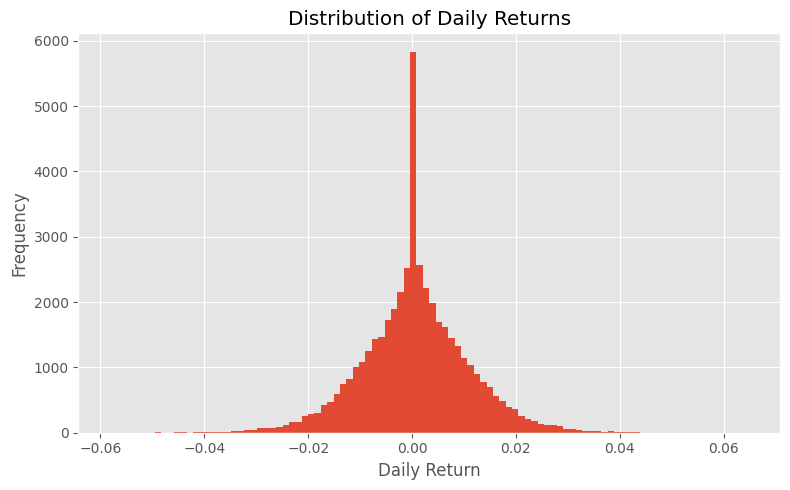

In [60]:
plt.figure(figsize=(8,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## CAGR Analysis

In [61]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [62]:
cagr_list = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code].sort_values("date")

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        (temp.iloc[-1]["date"] - temp.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_list.append([code, round(cagr, 2)])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "CAGR_%"]
)

cagr_df = cagr_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr_df = cagr_df[["amfi_code", "scheme_name", "CAGR_%"]]

cagr_df.head()

,amfi_code,scheme_name,CAGR_%
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2.64
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.46
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,23.54
4,101207,ABSL Small Cap Fund - Regular - Growth,7.94


In [63]:
cagr_df.describe()

,amfi_code,CAGR_%
count,40.000000,40.000000
mean,120247.000000,16.735500
std,14534.998667,10.308558
min,100016.000000,1.170000
25%,118632.750000,6.865000
50%,119551.500000,16.605000
75%,120842.250000,24.487500
max,149324.000000,32.830000


In [64]:
cagr_df.sort_values("CAGR_%", ascending=False).head()

,amfi_code,scheme_name,CAGR_%
25,120505,ICICI Pru Midcap Fund - Regular - Growth,32.83
21,119598,SBI Small Cap Fund - Regular Plan - Growth,32.42
39,149324,DSP Small Cap Fund - Regular - Growth,32.29
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,30.97


In [65]:
cagr_df.shape

(40, 3)

## Sharpe Ratio

In [66]:
rf_daily = 0.065 / 252

sharpe_list = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    returns = temp["daily_return"].dropna()

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe = ((mean_return - rf_daily) / std_return) * np.sqrt(252)

    sharpe_list.append([code, round(sharpe, 3)])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "Sharpe_Ratio"]
)

sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df = sharpe_df[["amfi_code", "scheme_name", "Sharpe_Ratio"]]

sharpe_df.head()

,amfi_code,scheme_name,Sharpe_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.202
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027
4,101207,ABSL Small Cap Fund - Regular - Growth,0.163


In [67]:
sharpe_df.shape

(40, 3)

In [68]:
sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

,amfi_code,scheme_name,Sharpe_Ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448
30,120843,Kotak Flexicap Fund - Regular - Growth,1.307
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235
19,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208
25,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180
38,149323,DSP Midcap Fund - Regular - Growth,1.132
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.082
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.027


## Sortino Ratio

In [69]:
rf_daily = 0.065 / 252

sortino_list = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    returns = temp["daily_return"].dropna()

    mean_return = returns.mean()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - rf_daily) / downside_std) * np.sqrt(252)

    sortino_list.append([code, round(sortino, 3)])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "Sortino_Ratio"]
)

sortino_df = sortino_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df = sortino_df[
    ["amfi_code", "scheme_name", "Sortino_Ratio"]
]

sortino_df.head()

,amfi_code,scheme_name,Sortino_Ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.351
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.942
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.800
4,101207,ABSL Small Cap Fund - Regular - Growth,0.277


In [70]:
sortino_df.shape

(40, 3)

In [71]:
sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

,amfi_code,scheme_name,Sortino_Ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.386
30,120843,Kotak Flexicap Fund - Regular - Growth,2.364
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.147
19,119551,SBI Bluechip Fund - Regular Plan - Growth,2.140
25,120505,ICICI Pru Midcap Fund - Regular - Growth,2.029
38,149323,DSP Midcap Fund - Regular - Growth,1.875
9,118632,Nippon India Large Cap Fund - Regular - Growth,1.850
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.805
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.800


## Alpha & Beta (OLS Regression)

In [72]:
from scipy.stats import linregress

In [73]:
# Use NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Compute benchmark daily returns
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta_list = []

for code in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == code][
        ["date", "daily_return"]
    ]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    if len(merged) > 10:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

    else:
        alpha = np.nan
        beta = np.nan

    alpha_beta_list.append([code, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta_df = alpha_beta_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

alpha_beta_df = alpha_beta_df[
    ["amfi_code", "scheme_name", "Alpha", "Beta"]
]

alpha_beta_df.head()

,amfi_code,scheme_name,Alpha,Beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [74]:
alpha_beta_df.shape

(40, 4)

In [75]:
alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
)

,amfi_code,scheme_name,Alpha,Beta
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196
39,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134
30,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684
38,149323,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523
16,119094,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751


In [76]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

## Maximum Drawdown

In [77]:
maxdd_list = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code].sort_values("date").copy()

    # Running maximum NAV
    temp["running_max"] = temp["nav"].cummax()

    # Drawdown
    temp["drawdown"] = (temp["nav"] / temp["running_max"]) - 1

    # Maximum drawdown
    max_dd = temp["drawdown"].min()

    # Worst drawdown date
    worst_date = temp.loc[temp["drawdown"].idxmin(), "date"]

    maxdd_list.append([code, max_dd, worst_date])

maxdd_df = pd.DataFrame(
    maxdd_list,
    columns=["amfi_code", "Max_Drawdown", "Worst_Date"]
)

maxdd_df = maxdd_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

maxdd_df = maxdd_df[
    ["amfi_code", "scheme_name", "Max_Drawdown", "Worst_Date"]
]

maxdd_df.head()

,amfi_code,scheme_name,Max_Drawdown,Worst_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11


In [78]:
maxdd_df.shape

(40, 4)

In [79]:
maxdd_df.sort_values("Max_Drawdown")

,amfi_code,scheme_name,Max_Drawdown,Worst_Date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2025-10-28
17,119095,Axis Small Cap Fund - Regular - Growth,-0.516778,2026-05-11
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,-0.311719,2025-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2025-05-14
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.280011,2026-04-27
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-09-15
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2024-10-17
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2026-02-20
15,119093,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22


## Fund Scorecard

In [80]:
# Create ranking dataframe
scorecard = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

# Add Sharpe
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

# Add Alpha
scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

# Add Max Drawdown
scorecard = scorecard.merge(
    maxdd_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code"
)

# Compute ranks
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

# Composite Score
scorecard["Fund_Score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

# Convert to 0–100 scale
scorecard["Fund_Score"] = (
    100 * (scorecard["Fund_Score"].max() - scorecard["Fund_Score"])
    / (scorecard["Fund_Score"].max() - scorecard["Fund_Score"].min())
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Max_Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.307,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.094,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,90.719258


In [81]:
scorecard.shape

(40, 13)

In [82]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

## Benchmark Comparison

In [83]:
top5 = scorecard.head(5)

top5

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Max_Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.307,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.094,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,90.719258


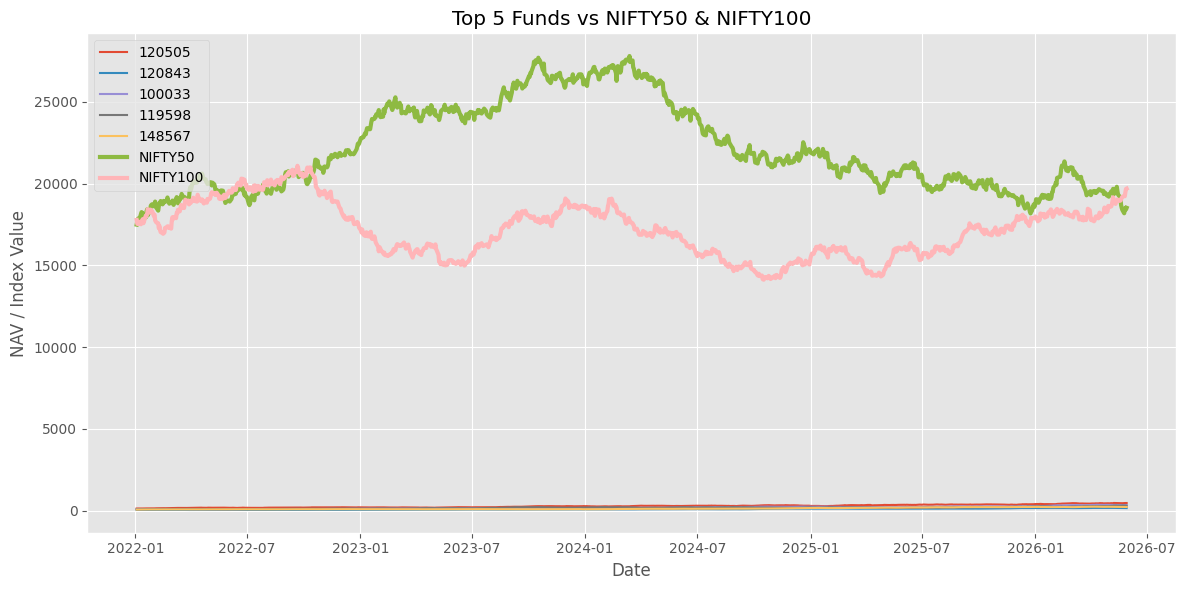

In [84]:
plt.figure(figsize=(12,6))

# Plot Top 5 Funds
for code in top5["amfi_code"]:

    temp = nav[nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

# Plot NIFTY50
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linewidth=3,
    label="NIFTY50"
)

# Plot NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()
plt.tight_layout()
plt.show()

In [85]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [86]:
tracking_error_list = []

for code in top5["amfi_code"]:

    fund_returns = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error_list.append(
        [code, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_list,
    columns=["amfi_code", "Tracking_Error"]
)

tracking_error_df

,amfi_code,Tracking_Error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


In [87]:
scorecard.to_csv("fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

In [88]:
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [89]:
plt.show()

## Key Findings

1. Daily returns across the 40 mutual fund schemes were centered around zero with limited extreme outliers, indicating a realistic return distribution.

2. CAGR analysis showed noticeable variation in long-term performance across schemes, highlighting differences in fund management effectiveness.

3. Funds with higher Sharpe Ratios delivered better risk-adjusted returns compared to peers.

4. Sortino Ratios indicated that some funds managed downside risk more effectively than others.

5. Alpha and Beta analysis showed varying sensitivity of funds to market movements, with several funds generating positive alpha.

6. Maximum Drawdown analysis identified the worst historical decline experienced by each fund, reflecting downside risk.

7. The composite Fund Scorecard successfully ranked all schemes based on return, risk-adjusted performance, alpha, expense ratio, and drawdown.

8. Benchmark comparison showed that top-performing funds outperformed or closely tracked major market indices over the analysis period.

9. Tracking Error values indicated differing levels of deviation from the benchmark across the top funds.

10. Overall, combining multiple performance metrics provides a more balanced evaluation than relying on returns alone.